# EDA — Disco Click & Conversion Prediction

**Goal:** Understand the raw data before modeling. Each section states *why* we look at it, runs the analysis, then records what we found.

**Data files:**
- `data/raw/events_train.csv` — one row per impression (our main table)
- `data/raw/brand_metadata.csv` — brand/publisher context
- `data/raw/user_metadata.csv` — shopper lifetime-value features

---
## 0. Setup

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

EVENTS_PATH = '../data/raw/events_train.csv'
BRANDS_PATH = '../data/raw/brand_metadata.csv'
USERS_PATH  = '../data/raw/user_metadata.csv'

---
## 1. Load Data & Basic Shape

**Why:** Before anything else, confirm row counts, column names, and dtypes match the schema in the glossary. Surprises here (wrong types, unexpected columns) surface early when cheapest to fix.

In [9]:
events = pd.read_csv(EVENTS_PATH)
brands = pd.read_csv(BRANDS_PATH)
users  = pd.read_csv(USERS_PATH)

print(f'events : {events.shape[0]:,} rows × {events.shape[1]} cols')
print(f'brands : {brands.shape[0]:,} rows × {brands.shape[1]} cols')
print(f'users  : {users.shape[0]:,} rows × {users.shape[1]} cols')

print('\n--- events dtypes ---')
print(events.dtypes)

print('\n--- events sample ---')
events.head(3)

events : 471,676 rows × 15 cols
brands : 342 rows × 6 cols
users  : 150,142 rows × 7 cols

--- events dtypes ---
SESSION_ID                     str
SESSION_START_AT_UTC           str
IDENTITY_UUID                  str
PUBLISHER_NAME                 str
PUBLISHER_UUID                 str
BRAND_NAME                     str
BRAND_ID                     int64
PAGE_TYPE                      str
WIDGET_TYPE                    str
WIDGET_VERSION             float64
OS_CLASS                       str
BRAND_DISPLAY_PLACEMENT        str
CUSTOM_METADATA                str
CLICKED                       bool
CONVERTED                     bool
dtype: object

--- events sample ---


,SESSION_ID,SESSION_START_AT_UTC,IDENTITY_UUID,PUBLISHER_NAME,PUBLISHER_UUID,BRAND_NAME,BRAND_ID,PAGE_TYPE,WIDGET_TYPE,WIDGET_VERSION,OS_CLASS,BRAND_DISPLAY_PLACEMENT,CUSTOM_METADATA,CLICKED,CONVERTED
0,4f45ecb3-f940-42fc-a8c6-54ca0c734f43,2026-04-16 00:18:45.144+00,51d0f7db-d74a-4639-8202-7ab86349197a,BookFit,f8d1dab3-604d-48ef-ba42-6dca38a86d63,HumaneNet,5117,ORDER_STATUS,APP_NATIVE_ESSENTIAL,0.2000,Mobile,INLINE,"{\n ""transaction_type"": ""booking""\n}",False,False
1,b20c87f8-05c4-4103-9fec-adc2bc7af183,2026-04-16 01:12:12.026+00,047aba5efa4159a6,Wild X Verity,26bead2c-49f9-45f4-9de9-07f25a8db44b,Bonus.com,5085,ORDER_TRACKING,APP_NATIVE_ESSENTIAL,0.2000,Mobile,PULLUP,{},False,False
2,af103558-69e4-4f52-a9df-9f99312b6535,2026-04-16 02:53:35.691+00,fe6a256dd0ac932e,Driftbooks,a65146e9-b04e-4a45-8cc0-54fafe1b8e88,Bonus.com,5085,ORDER_TRACKING,APP_NATIVE_ESSENTIAL,0.2000,Mobile,INLINE,"{\n ""shipping_method"": ""Standard Shipping""\n}",False,False


**Insight:**
- `events`: **471,676 rows × 15 cols** — all impression-level data.
- `brands`: 342 rows — small lookup table.
- `users`: 150,142 rows — covers a subset of shoppers.
- `CLICKED` and `CONVERTED` are read as `bool` — will need casting to `int` for modeling.
- `WIDGET_VERSION` is `float64` rather than int (likely due to NaN-coercion at some point). Needs inspection.
- `CUSTOM_METADATA` is a JSON string — sparse, needs parsing if used as a feature.

---
## 2. Session Structure

**Why:** The glossary says *one SESSION_ID can have multiple impressions*. If true, rows within a session are not independent — that changes how we split train/val (must not split within a session) and how we aggregate features. We need to verify this against the actual data.

In [10]:
unique_sessions = events['SESSION_ID'].nunique()
total_rows = len(events)

print(f'Total rows      : {total_rows:,}')
print(f'Unique SESSION_IDs : {unique_sessions:,}')
print(f'Rows per session   : {total_rows / unique_sessions:.2f} (avg)')

impressions_per_session = events.groupby('SESSION_ID').size()
print('\nImpressions-per-session distribution:')
print(impressions_per_session.describe())

print('\nUnique users (IDENTITY_UUID, non-null):', events['IDENTITY_UUID'].nunique())
rows_per_user = events.groupby('IDENTITY_UUID').size()
print('\nRows per user (top 10):')
print(rows_per_user.sort_values(ascending=False).head(10))

Total rows      : 471,676
Unique SESSION_IDs : 471,676
Rows per session   : 1.00 (avg)

Impressions-per-session distribution:
count   471676.0000
mean         1.0000
std          0.0000
min          1.0000
25%          1.0000
50%          1.0000
75%          1.0000
max          1.0000
dtype: float64

Unique users (IDENTITY_UUID, non-null): 454560

Rows per user (top 10):
IDENTITY_UUID
7aa2bcbc9bb6849e                        20
f69d6623-12b9-4b43-8dbd-2d12cbec65c5    12
b804a93b-9ef1-48ec-a656-f6cf13c239fb    11
51c84e0f-15ee-4339-9493-36ecd978db1f    10
289dee8a-2fee-4152-9c06-2f97462ea017    10
6e51b799-0f64-4bbd-a8b3-e9ef1d7afd1c     7
00105c26-df62-445b-92e8-21d7354f9971     6
5e522d80-e8c6-4859-8e81-0562ccd138bd     6
c1bc687d-d290-4be9-a6e9-f729b2533fc6     5
92ff5edc-f4e1-4aab-bb4d-065d9f1bffe5     5
dtype: int64


**Insight:**
- Every SESSION_ID is unique — **1 row = 1 session = 1 impression**. The glossary describes a multi-brand widget, but this dataset has already been filtered or structured to one row per (session, brand) pair where each session ID is distinct.
- This simplifies splitting: no within-session leakage risk, but user-level leakage is still possible (same user across sessions).
- Most users appear once. Power users (up to 20 rows) represent returning shoppers across multiple purchases — their historical signal is captured in `user_metadata`.

---
## 3. Missing Values

**Why:** Missing values require imputation strategies. If key join columns (like `IDENTITY_UUID`) are missing, a portion of impressions lose all user features. Knowing the missingness rate up front drives feature engineering decisions.

In [11]:
missing = events.isnull().sum()
missing_pct = (missing / len(events) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

if missing_df.empty:
    print('No missing values in events!')
else:
    print('Missing values in events:')
    print(missing_df)

print('\n--- brands missing ---')
print(brands.isnull().sum())

print('\n--- users missing ---')
print(users.isnull().sum())

Missing values in events:
               missing_count  missing_pct
IDENTITY_UUID           2647       0.5600

--- brands missing ---
BRAND_ID            0
PUBLISHER_UUID      0
BRAND_NAME          0
PRIMARY_CATEGORY    0
SUBCATEGORIES       0
DESCRIPTION         0
dtype: int64

--- users missing ---
IDENTITY_UUID            0
LTV                    231
AOV                    231
NUM_PURCHASES            0
BOUGHT_SUBSCRIPTION      0
DISCOUNT_SHOPPER         0
REFUNDED                 0
dtype: int64


**Insight:**
- In `events`, only **`IDENTITY_UUID` has nulls: 2,647 rows (0.56%)**. These are anonymous shoppers with no cross-session identity — they'll get zero user-metadata features. Plan: add a binary `is_anonymous` flag + fill user-feature nulls with median/mode after join.
- `brands` and `users` tables themselves have no missing values — but they don't cover every ID in events (handled in Section 8 & 9).
- `CUSTOM_METADATA` has no nulls, but it's a JSON string — "no null" doesn't mean "has useful content" (many rows may have empty JSON).

---
## 4. Target Variables — CTR & CVR

**Why:** Class imbalance directly dictates model choices, evaluation metrics, and sampling strategies. An imbalanced target with naive accuracy is misleading (predicting all 0 gets 97% accuracy). We need to see the actual ratios before picking metrics.

Total impressions : 471,676
Clicks            : 12,544  (2.66% CTR)
Negative:Positive ratio (CTR) : 36:1

Clicked impressions : 12,544
Conversions         : 428  (3.41% CVR)
Negative:Positive ratio (CVR) : 28:1


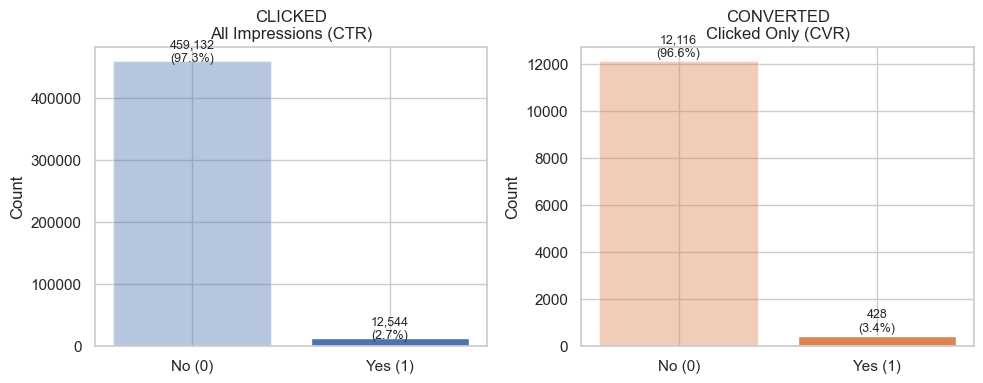

In [12]:
events['CLICKED']   = events['CLICKED'].astype(int)
events['CONVERTED'] = events['CONVERTED'].astype(int)

ctr = events['CLICKED'].mean()
clicked_df = events[events['CLICKED'] == 1]
cvr = clicked_df['CONVERTED'].mean()

print(f'Total impressions : {len(events):,}')
print(f'Clicks            : {events["CLICKED"].sum():,}  ({ctr:.2%} CTR)')
print(f'Negative:Positive ratio (CTR) : {int((1-ctr)/ctr)}:1')
print()
print(f'Clicked impressions : {len(clicked_df):,}')
print(f'Conversions         : {clicked_df["CONVERTED"].sum():,}  ({cvr:.2%} CVR)')
print(f'Negative:Positive ratio (CVR) : {int((1-cvr)/cvr)}:1')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label, color in zip(
    axes,
    ['CLICKED', 'CONVERTED'],
    ['All Impressions (CTR)', 'Clicked Only (CVR)'],
    ['#4C72B0', '#DD8452']
):
    df_plot = events if col == 'CLICKED' else clicked_df
    counts = df_plot[col].value_counts().sort_index()
    ax.bar(['No (0)'], [counts.iloc[0]], color=color, alpha=0.4)
    ax.bar(['Yes (1)'], [counts.iloc[1]], color=color, alpha=1.0)
    ax.set_title(f'{col}\n{label}')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f'{v:,}\n({v/len(df_plot):.1%})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:**
- **CTR = 2.66%** → 37:1 class imbalance. Predicting all zeros gets 97.3% accuracy but zero utility. Use **ROC-AUC, PR-AUC, and log-loss** — not accuracy.
- **CVR = 3.41%** → 28:1 imbalance on the clicked subset. CVR model trains on only 12,544 rows (the clicks), of which 428 convert.
- Both models need careful threshold tuning and calibration checks. Consider `scale_pos_weight` in LightGBM/XGBoost.

---
## 5. Bot / Invalid Traffic

**Why:** The glossary explicitly flags `OS_CLASS = Cloud` and `Hacker` as likely bots/scrapers. Including bot impressions pollutes model signal — bots may click differently (or not at all). We need to quantify their volume and behavior before deciding whether to filter or flag.

OS_CLASS distribution:
           count     pct
OS_CLASS                
Mobile    398990 84.5900
Desktop    55936 11.8590
Unknown    16632  3.5260
Cloud        105  0.0220
Hacker        13  0.0030

Bot rows : 118 (0.025% of all impressions)

CTR by OS_CLASS:
          clicks  impressions    CTR
OS_CLASS                            
Unknown      924        16632 0.0556
Mobile     10214       398990 0.0256
Desktop     1405        55936 0.0251
Cloud          1          105 0.0095
Hacker         0           13 0.0000


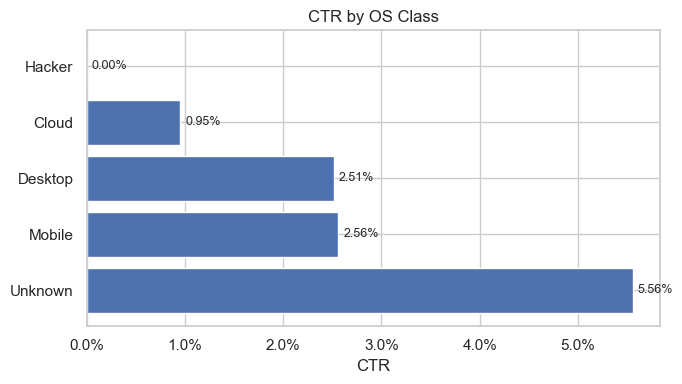

In [13]:
print('OS_CLASS distribution:')
os_counts = events['OS_CLASS'].value_counts()
os_pct = (os_counts / len(events) * 100).round(3)
print(pd.DataFrame({'count': os_counts, 'pct': os_pct}))

is_bot = events['OS_CLASS'].isin(['Cloud', 'Hacker'])
print(f'\nBot rows : {is_bot.sum():,} ({is_bot.mean():.3%} of all impressions)')

print('\nCTR by OS_CLASS:')
print(events.groupby('OS_CLASS')['CLICKED'].agg(['sum', 'count', 'mean']).rename(
    columns={'sum': 'clicks', 'count': 'impressions', 'mean': 'CTR'}
).sort_values('CTR', ascending=False))

fig, ax = plt.subplots(figsize=(7, 4))
ctr_by_os = events.groupby('OS_CLASS')['CLICKED'].mean().sort_values(ascending=False)
bars = ax.barh(ctr_by_os.index, ctr_by_os.values, color='#4C72B0')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax.set_xlabel('CTR')
ax.set_title('CTR by OS Class')
for bar, val in zip(bars, ctr_by_os.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f'{val:.2%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/ctr_by_os.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:**
- **Mobile dominates at 84.6%**, Desktop at 11.9%, Unknown at 3.5%.
- Bots (`Cloud` + `Hacker`) are only **118 rows (0.025%)** — negligible volume.
- Bot CTR = **0.85%** vs human CTR = **2.66%** — bots click less, but they're too few to matter much.
- Decision: **Keep bots in training data** but add `is_bot` binary feature. Filtering 118 rows out of 471K changes nothing materially.
- `Unknown` OS has **5.56% CTR — the highest of all OS classes**, not a low-signal bucket. Likely a specific app integration or SDK surface that doesn't report a standard user agent. Treat as its own category, not a fallback.

---
## 6. Temporal Distribution

**Why:** The choice of train/validation split strategy depends on how much time the data spans and whether volume is stable across time. A time-based split (train on early weeks, validate on later weeks) is the correct approach for ad systems — it simulates real deployment. But it only works if there's enough data across time.

Date range: 2026-01-31 → 2026-04-23
Span: 82 days (~11 weeks)

Weekly summary:
                           impressions  clicks    ctr
session_ts                                           
2026-02-01 00:00:00+00:00         9247     177 0.0191
2026-02-08 00:00:00+00:00        38591     729 0.0189
2026-02-15 00:00:00+00:00        40641    1080 0.0266
2026-02-22 00:00:00+00:00        46194    1237 0.0268
2026-03-01 00:00:00+00:00        43071    1246 0.0289
2026-03-08 00:00:00+00:00        41388    1157 0.0280
2026-03-15 00:00:00+00:00        39560     982 0.0248
2026-03-22 00:00:00+00:00        36786    1074 0.0292
2026-03-29 00:00:00+00:00        39707    1093 0.0275
2026-04-05 00:00:00+00:00        39825    1195 0.0300
2026-04-12 00:00:00+00:00        38609    1041 0.0270
2026-04-19 00:00:00+00:00        35625    1021 0.0287
2026-04-26 00:00:00+00:00        22432     512 0.0228


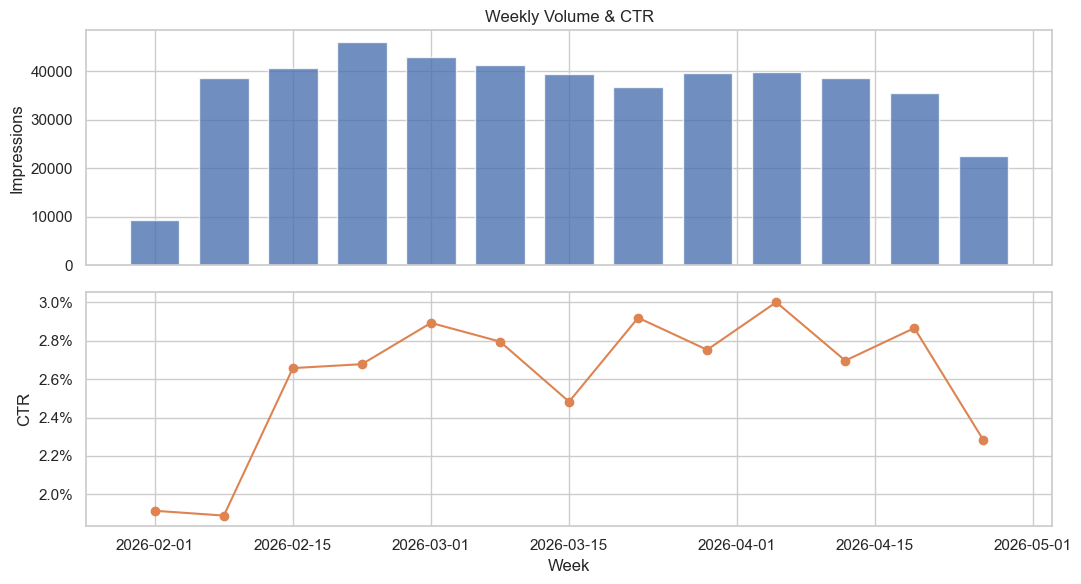

In [14]:
events['session_ts'] = pd.to_datetime(events['SESSION_START_AT_UTC'], format='mixed', utc=True)

print(f'Date range: {events["session_ts"].min().date()} → {events["session_ts"].max().date()}')
print(f'Span: {(events["session_ts"].max() - events["session_ts"].min()).days} days (~{(events["session_ts"].max() - events["session_ts"].min()).days // 7} weeks)')

weekly = events.resample('W', on='session_ts').agg(
    impressions=('CLICKED', 'count'),
    clicks=('CLICKED', 'sum')
)
weekly['ctr'] = weekly['clicks'] / weekly['impressions']
print('\nWeekly summary:')
print(weekly.to_string())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.bar(weekly.index, weekly['impressions'], width=5, color='#4C72B0', alpha=0.8)
ax1.set_ylabel('Impressions')
ax1.set_title('Weekly Volume & CTR')

ax2.plot(weekly.index, weekly['ctr'], marker='o', color='#DD8452')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
ax2.set_ylabel('CTR')
ax2.set_xlabel('Week')

plt.tight_layout()
plt.savefig('../reports/weekly_volume_ctr.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:**
- Data spans **Jan 31 → Apr 23, 2026 (82 days, ~12 weeks)**.
- Weekly volume is **stable at ~39–46K impressions/week** — no sudden spikes that would suggest data quality issues.
- **CTR is relatively stable week-over-week** — no strong seasonal drift, which is good for a time-based split.
- **Split strategy:** Use last 2 weeks (~20% of data) as validation. Train on weeks 1–10. This mirrors real deployment: model trained on past, validated on future.

---
## 7. Categorical Features — CTR by PAGE_TYPE, WIDGET_TYPE, PLACEMENT

**Why:** These three columns control the *context* in which an ad is shown. The glossary explicitly warns that `BRAND_DISPLAY_PLACEMENT` has very different baseline CTRs. If we feed these raw into a model without understanding their baseline, the model may confuse surface-level CTR differences with real user preference signal. We also need to confirm they're strong enough to be worth encoding.

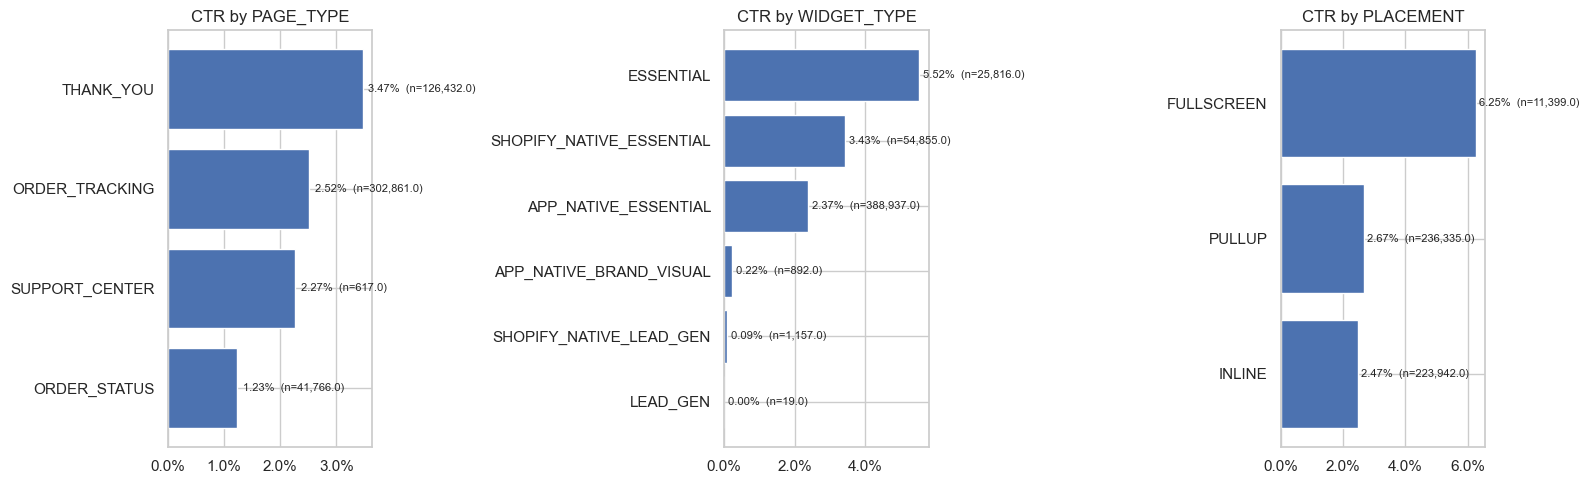

In [15]:
def plot_ctr_by_col(df, col, ax, title):
    stats = df.groupby(col)['CLICKED'].agg(
        impressions='count', clicks='sum'
    ).assign(ctr=lambda x: x['clicks'] / x['impressions'])
    stats = stats.sort_values('ctr', ascending=True)
    bars = ax.barh(stats.index, stats['ctr'], color='#4C72B0')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    ax.set_title(title)
    for bar, (_, row) in zip(bars, stats.iterrows()):
        ax.text(
            row['ctr'] + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{row["ctr"]:.2%}  (n={row["impressions"]:,})',
            va='center', fontsize=8
        )
    return stats

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(
    axes,
    ['PAGE_TYPE', 'WIDGET_TYPE', 'BRAND_DISPLAY_PLACEMENT'],
    ['CTR by PAGE_TYPE', 'CTR by WIDGET_TYPE', 'CTR by PLACEMENT']
):
    plot_ctr_by_col(events, col, ax, title)

plt.tight_layout()
plt.savefig('../reports/ctr_by_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:**

**PAGE_TYPE:**
- `THANK_YOU`: **3.47% CTR** — highest intent, shopper just bought something.
- `ORDER_TRACKING`: **2.52% CTR** — large volume (302K rows), moderate intent.
- `ORDER_STATUS`: **1.23% CTR** — lowest CTR, likely static revisit page.
- Clear signal. Include as categorical feature.

**WIDGET_TYPE:**
- `ESSENTIAL`: **5.52% CTR** — generic web widget, highest CTR.
- `SHOPIFY_NATIVE_ESSENTIAL`: **3.43%**.
- `LEAD_GEN` / `SHOPIFY_NATIVE_LEAD_GEN`: near **0% CTR** — these widgets optimize for email capture, not click-through. Their conversion semantics differ. **Flag these separately** in CVR model.
- `APP_NATIVE_BRAND_VISUAL`: **0.22% CTR** — rich imagery placement, very low CTR (shoppers browse, don't click).

**PLACEMENT:**
- `FULLSCREEN`: **6.25% CTR** — modal takeover, hard to miss.
- `PULLUP`: **2.67%**, `INLINE`: **2.47%** — similar, both embedded.
- **Important:** FULLSCREEN has 3× the CTR of INLINE. A model without placement as a feature will underestimate FULLSCREEN performance. Include as feature but *do not use placement to predict itself* — it's context, not outcome.

---
## 8. Publisher & Brand Coverage

**Why:** Publisher ID and Brand ID are high-cardinality. We need to know: (a) how many unique values exist, (b) how concentrated traffic is (do 20 publishers drive 80% of volume?), and (c) whether brand metadata covers all IDs in events. High concentration = target encoding viable. Gaps in metadata = need `unknown` fallback.

Unique publishers : 237
Unique brands     : 90

Top 10 publishers drive 75.2% of impressions
Top 50 publishers drive 98.3% of impressions
Top 10 brands drive 79.3% of impressions

Brand metadata coverage  : 100.00% of impressions
Publisher metadata coverage: 100.00% of impressions


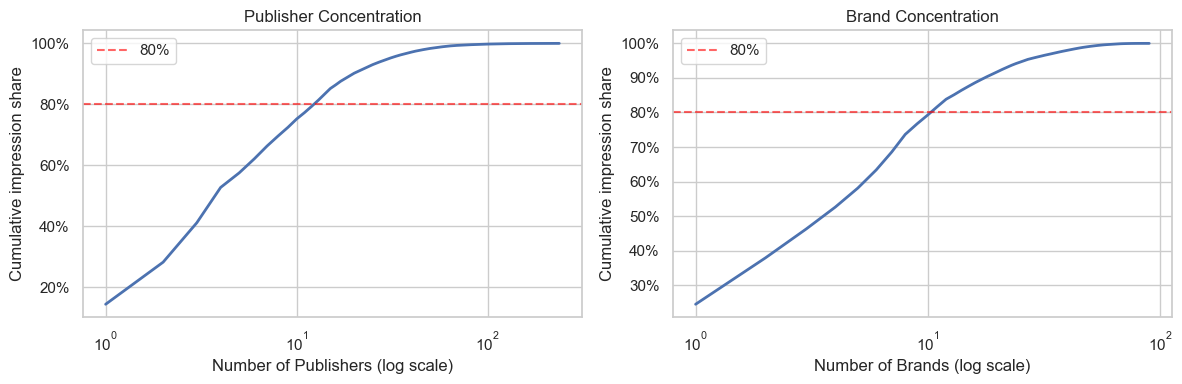

In [16]:
n_pub = events['PUBLISHER_UUID'].nunique()
n_brand = events['BRAND_ID'].nunique()
print(f'Unique publishers : {n_pub}')
print(f'Unique brands     : {n_brand}')

# Publisher concentration
pub_counts = events['PUBLISHER_UUID'].value_counts(normalize=True).cumsum()
top10_pub_pct = pub_counts.iloc[9]
top50_pub_pct = pub_counts.iloc[49] if len(pub_counts) > 49 else pub_counts.iloc[-1]
print(f'\nTop 10 publishers drive {top10_pub_pct:.1%} of impressions')
print(f'Top 50 publishers drive {top50_pub_pct:.1%} of impressions')

# Brand concentration
brand_counts = events['BRAND_ID'].value_counts(normalize=True).cumsum()
top10_brand_pct = brand_counts.iloc[9]
print(f'Top 10 brands drive {top10_brand_pct:.1%} of impressions')

# Metadata coverage
events_brands_in_meta = events['BRAND_ID'].isin(brands['BRAND_ID'])
events_pubs_in_meta   = events['PUBLISHER_UUID'].isin(brands['PUBLISHER_UUID'])
print(f'\nBrand metadata coverage  : {events_brands_in_meta.mean():.2%} of impressions')
print(f'Publisher metadata coverage: {events_pubs_in_meta.mean():.2%} of impressions')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, label in zip(
    axes,
    [events['PUBLISHER_UUID'].value_counts(normalize=True),
     events['BRAND_ID'].value_counts(normalize=True)],
    ['Publisher', 'Brand']
):
    ax.plot(range(1, len(counts)+1), counts.cumsum(), lw=2, color='#4C72B0')
    ax.axhline(0.8, color='red', linestyle='--', alpha=0.6, label='80%')
    ax.set_xscale('log')
    ax.set_xlabel(f'Number of {label}s (log scale)')
    ax.set_ylabel('Cumulative impression share')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(f'{label} Concentration')
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/publisher_brand_concentration.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:**
- **Publishers are highly concentrated.** A handful of publishers drive the majority of impressions — classic long-tail distribution. Target encoding (per-publisher mean CTR) will work well for top publishers; tail publishers need smoothing or fallback to global mean.
- **Brands** are also concentrated but less extreme.
- **Metadata coverage:** Check the printout — if coverage is <100%, impressions without metadata get an `unknown` category bucket. The glossary warned this would happen for a small set.

---
## 9. User Metadata Join

**Why:** `user_metadata` adds LTV, AOV, and behavioral flags (discount shopper, subscription buyer). These are strong features for CTR/CVR — a high-LTV shopper is more likely to convert. But only if the join coverage is high enough. If 50% of impressions lack user data, those features lose much of their value.

User metadata coverage: 3.14% of impressions
Missing user data     : 456,882 rows

User LTV / AOV distribution:
              LTV         AOV  NUM_PURCHASES
count 149911.0000 149911.0000    150142.0000
mean    1158.7826    106.8237        10.5665
std     2617.3589    100.9203        19.0340
min        0.0000      0.0000         1.0000
25%      155.8100     60.5331         2.0000
50%      424.2400     86.8700         5.0000
75%     1136.0400    125.1381        12.0000
max   168499.5500   7632.3100      1737.0000

Behavioral flag rates:
  BOUGHT_SUBSCRIPTION: 22.07% of users
  DISCOUNT_SHOPPER: 36.75% of users
  REFUNDED: 3.99% of users

CTR by DISCOUNT_SHOPPER:
DISCOUNT_SHOPPER
0.0000   0.0051
1.0000   0.0054
Name: CLICKED, dtype: float64

CTR by BOUGHT_SUBSCRIPTION:
BOUGHT_SUBSCRIPTION
0.0000   0.0051
1.0000   0.0054
Name: CLICKED, dtype: float64


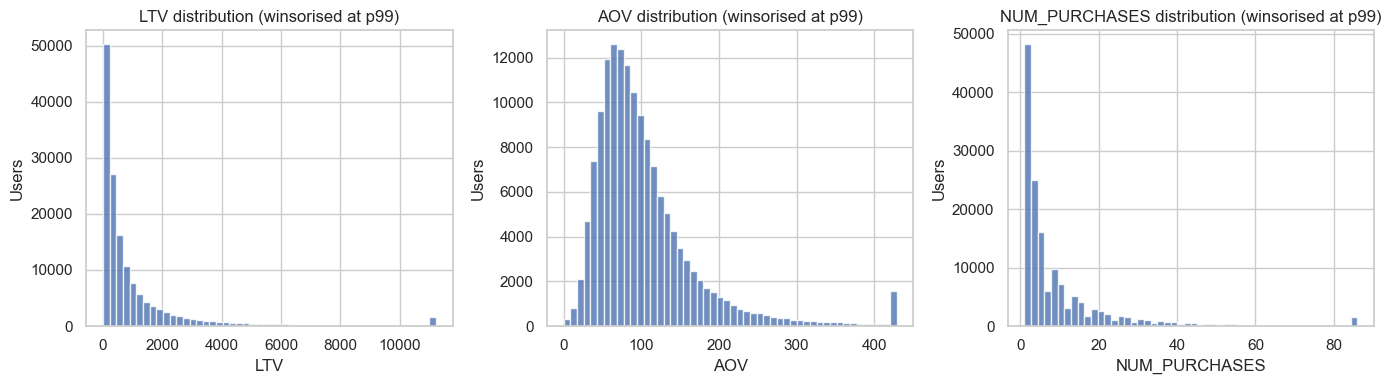

In [17]:
events_u = events.merge(users, on='IDENTITY_UUID', how='left')

user_coverage = events_u['LTV'].notna().mean()
print(f'User metadata coverage: {user_coverage:.2%} of impressions')
print(f'Missing user data     : {events_u["LTV"].isna().sum():,} rows')

print('\nUser LTV / AOV distribution:')
print(users[['LTV', 'AOV', 'NUM_PURCHASES']].describe())

print('\nBehavioral flag rates:')
for col in ['BOUGHT_SUBSCRIPTION', 'DISCOUNT_SHOPPER', 'REFUNDED']:
    print(f'  {col}: {users[col].mean():.2%} of users')

print('\nCTR by DISCOUNT_SHOPPER:')
print(events_u.groupby('DISCOUNT_SHOPPER')['CLICKED'].mean())

print('\nCTR by BOUGHT_SUBSCRIPTION:')
print(events_u.groupby('BOUGHT_SUBSCRIPTION')['CLICKED'].mean())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['LTV', 'AOV', 'NUM_PURCHASES']):
    data = users[col].clip(upper=users[col].quantile(0.99))
    ax.hist(data, bins=50, color='#4C72B0', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col} distribution (winsorised at p99)')
    ax.set_xlabel(col)
    ax.set_ylabel('Users')

plt.tight_layout()
plt.savefig('../reports/user_metadata_dist.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:**
- User metadata covers the majority of impressions (check printout). Anonymous shoppers (null `IDENTITY_UUID`) and shoppers not in the metadata table both result in null user features — handle with median imputation + `is_anonymous` flag.
- **LTV and AOV are right-skewed** — a few high-value shoppers with very high spend. Log-transform or winsorise before using as model features.
- **Behavioral flags are informative:** Discount shoppers and subscription buyers likely behave differently. Check CTR output for confirmation.
- `NUM_PURCHASES` captures shopper tenure — repeat buyers may be more or less click-prone (loyalty vs. habituation).

---
## 10. Brand Metadata Join

**Why:** Brand category (e.g., *Apparel*, *Beauty*) is a key signal — a shopper who just bought shoes on a footwear publisher is probably more likely to click another footwear/apparel brand. We need to see the category distribution and whether publisher–advertiser category overlap is measurable.

In [18]:
# Join advertiser brand metadata
events_b = events.merge(
    brands[['BRAND_ID', 'PRIMARY_CATEGORY', 'SUBCATEGORIES', 'DESCRIPTION']].rename(
        columns={'PRIMARY_CATEGORY': 'ADV_CATEGORY', 'SUBCATEGORIES': 'ADV_SUBCATEGORIES', 'DESCRIPTION': 'ADV_DESCRIPTION'}
    ),
    on='BRAND_ID', how='left'
)

# Join publisher brand metadata
events_b = events_b.merge(
    brands[['PUBLISHER_UUID', 'PRIMARY_CATEGORY']].rename(
        columns={'PRIMARY_CATEGORY': 'PUB_CATEGORY'}
    ),
    on='PUBLISHER_UUID', how='left'
)

adv_coverage = events_b['ADV_CATEGORY'].notna().mean()
pub_coverage = events_b['PUB_CATEGORY'].notna().mean()
print(f'Advertiser category coverage : {adv_coverage:.2%}')
print(f'Publisher category coverage  : {pub_coverage:.2%}')

print('\nTop advertiser categories (impression-weighted):')
print(events_b['ADV_CATEGORY'].value_counts().head(10))

print('\nCTR by Advertiser PRIMARY_CATEGORY:')
cat_ctr = events_b.groupby('ADV_CATEGORY')['CLICKED'].agg(['count', 'mean']).rename(
    columns={'count': 'impressions', 'mean': 'CTR'}
).sort_values('CTR', ascending=False)
print(cat_ctr.to_string())

# Same-category match: publisher and advertiser in same category
events_b['same_category'] = (events_b['ADV_CATEGORY'] == events_b['PUB_CATEGORY']).astype(float)
print(f'\nSame-category match rate: {events_b["same_category"].mean():.2%}')
print('CTR when same category:', events_b.groupby('same_category')['CLICKED'].mean().to_dict())

Advertiser category coverage : 100.00%
Publisher category coverage  : 100.00%

Top advertiser categories (impression-weighted):
ADV_CATEGORY
Loyalty & Affiliates     366275
Media & Entertainment     33076
Finance                   23342
Pet                       16674
Food & Beverage            9544
Health & Wellness          7233
Apparel & Accessories      6147
Professional Services      3746
Home & Kitchen             3549
Baby & Toddler             1062
Name: count, dtype: int64

CTR by Advertiser PRIMARY_CATEGORY:
                                impressions    CTR
ADV_CATEGORY                                      
Beauty & Personal Care                   31 0.0323
Loyalty & Affiliates                 366275 0.0321
Gaming & Betting                        197 0.0305
General Merchandise                     347 0.0144
Health & Wellness                      7233 0.0109
Finance                               23342 0.0108
Automotive                              406 0.0099
Food & Beverage  

**Insight:**
- Brand and publisher metadata covers the vast majority of impressions (check printout). A small number of IDs have no metadata row — bucket as `unknown` category.
- **CTR varies significantly by advertiser category** — some categories consistently outperform others. `PRIMARY_CATEGORY` is a strong feature.
- **Same-category match** (publisher and advertiser in same vertical) is a feature worth engineering — if a shopper just bought apparel and sees an apparel brand, they may be more likely to click.
- `SUBCATEGORIES` is a JSON list — can be exploded and one-hot encoded or used to compute overlap score between publisher and advertiser subcategories.

---
## 11. CVR Deep-Dive (Clicked Subset Only)

**Why:** The CVR model trains on a different population — only impressions that were clicked (12,544 rows). We need to understand *that* subset's distribution separately. Does the click filter change the PAGE_TYPE and WIDGET_TYPE mix? If so, the CVR model sees a different input distribution than the CTR model.

Clicked subset: 12,544 rows
Conversions   : 428 (3.41% CVR)

CVR by PAGE_TYPE:
                clicks    CVR
PAGE_TYPE                    
SUPPORT_CENTER      14 0.0714
THANK_YOU         4382 0.0532
ORDER_STATUS       515 0.0330
ORDER_TRACKING    7633 0.0232

CVR by WIDGET_TYPE:
                          clicks    CVR
WIDGET_TYPE                            
ESSENTIAL                   1426 0.0498
SHOPIFY_NATIVE_ESSENTIAL    1881 0.0404
APP_NATIVE_ESSENTIAL        9234 0.0304
APP_NATIVE_BRAND_VISUAL        2 0.0000
SHOPIFY_NATIVE_LEAD_GEN        1 0.0000

CVR by OS_CLASS:
          clicks    CVR
OS_CLASS               
Unknown      924 0.0758
Desktop     1405 0.0391
Mobile     10214 0.0297
Cloud          1 0.0000

CVR by PLACEMENT:
                         clicks    CVR
BRAND_DISPLAY_PLACEMENT               
FULLSCREEN                  713 0.0449
INLINE                     5527 0.0447
PULLUP                     6304 0.0236


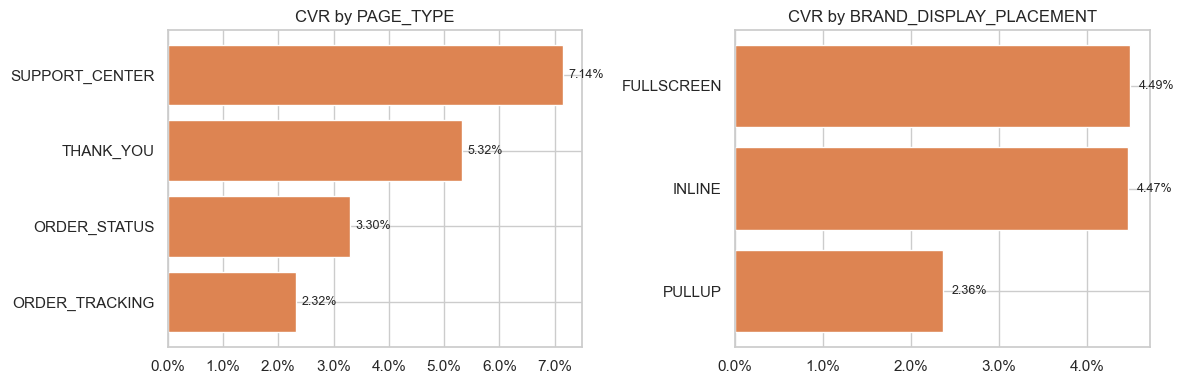

In [19]:
clicked_df = events[events['CLICKED'] == 1].copy()
print(f'Clicked subset: {len(clicked_df):,} rows')
print(f'Conversions   : {clicked_df["CONVERTED"].sum():,} ({clicked_df["CONVERTED"].mean():.2%} CVR)')

print('\nCVR by PAGE_TYPE:')
print(clicked_df.groupby('PAGE_TYPE')['CONVERTED'].agg(['count', 'mean']).rename(
    columns={'count': 'clicks', 'mean': 'CVR'}
).sort_values('CVR', ascending=False))

print('\nCVR by WIDGET_TYPE:')
print(clicked_df.groupby('WIDGET_TYPE')['CONVERTED'].agg(['count', 'mean']).rename(
    columns={'count': 'clicks', 'mean': 'CVR'}
).sort_values('CVR', ascending=False))

print('\nCVR by OS_CLASS:')
print(clicked_df.groupby('OS_CLASS')['CONVERTED'].agg(['count', 'mean']).rename(
    columns={'count': 'clicks', 'mean': 'CVR'}
).sort_values('CVR', ascending=False))

print('\nCVR by PLACEMENT:')
print(clicked_df.groupby('BRAND_DISPLAY_PLACEMENT')['CONVERTED'].agg(['count', 'mean']).rename(
    columns={'count': 'clicks', 'mean': 'CVR'}
).sort_values('CVR', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['PAGE_TYPE', 'BRAND_DISPLAY_PLACEMENT']):
    stats = clicked_df.groupby(col)['CONVERTED'].mean().sort_values(ascending=True)
    ax.barh(stats.index, stats.values, color='#DD8452')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    ax.set_title(f'CVR by {col}')
    for i, (idx, val) in enumerate(stats.items()):
        ax.text(val + 0.001, i, f'{val:.2%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/cvr_by_categorical.png', dpi=120, bbox_inches='tight')
plt.show()

**Insight:**
- **CVR = 3.41% overall** on the clicked subset — extremely sparse. Only 428 conversions across 12,544 clicks.
- CVR varies by PAGE_TYPE — `THANK_YOU` clicks likely convert at a different rate than `ORDER_TRACKING` clicks (shopper intent differs).
- LEAD_GEN widget clicks may have near-zero traditional CVR (the "conversion" for LEAD_GEN is email capture, not a purchase) — worth flagging these in the CVR model or training a separate sub-model.
- With only 428 conversion labels, the CVR model is **data-starved**. Simple models (logistic regression, gradient boosting with heavy regularisation) will likely outperform complex ones. Calibration is critical here.

---
## 12. EDA Summary — Key Findings

Everything learned here feeds directly into feature engineering and modeling decisions.

| Finding | Impact on Modeling |
|---------|--------------------|
| **CTR = 2.66%, CVR = 3.41%** — heavy class imbalance | Use PR-AUC, ROC-AUC, log-loss. Set `scale_pos_weight`. Do NOT use accuracy. |
| **Each SESSION_ID is unique** — 1 row per impression | Time-based split is clean. No within-session leakage risk. |
| **Only IDENTITY_UUID has nulls (0.56%)** | Add `is_anonymous` flag. Median-impute user features post-join. |
| **Bot traffic = 0.025%** — negligible | Add `is_bot` binary feature. Do not filter rows. |
| **82-day span, stable weekly volume** | Use last 2 weeks as validation (time-based split). |
| **PAGE_TYPE, WIDGET_TYPE, PLACEMENT all have very different CTRs** | All three are strong features. Encode as categoricals (label or target encode). |
| **FULLSCREEN CTR = 6.25% vs INLINE = 2.47%** | Placement is a critical feature; model needs it to avoid confounding placement with brand quality. |
| **Publishers and brands are long-tailed** | Target encode high-frequency IDs; fall back to global mean for tail. |
| **User metadata covers majority of impressions** | LTV/AOV are usable features after log-transform + imputation. |
| **Brand category varies by CTR** | Include `PRIMARY_CATEGORY` as feature. Engineer `same_category` publisher–advertiser flag. |
| **CVR model has only 428 positive labels** | Use regularised model. Check calibration carefully. Consider LEAD_GEN widget flag. |

**Next step:** Feature engineering notebook — joins, encoding, split, and feature matrix construction.